# Model 1 — Full Model, No Movement, No Temperature

This notebook is the **baseline version** of the salamander ATV model.

It keeps the full two-strata structure:
- offspring: `S`, `I`
- adults: `R_a`, `R_c`

It also keeps:
- births
- maturation
- environmental transmission
- cross-strata force of infection

But it removes:
- **movement**
- **temperature dependence**

So this version is meant to answer: **does the core model structure behave sensibly before adding movement or climate?**

In [1]:
# =====================
# Imports and SSL Setup
# =====================

import certifi
import os
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"] = certifi.where()

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from epymorph.kit import *  # noqa
from pathlib import Path
from sympy import Max

In [2]:
# =====================
# Load Custom Pond Data
# =====================

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path().resolve().parent

test_data_path = current_dir / "data" / "basicTestData.csv"
df = pd.read_csv(test_data_path)

site_ids = df["site_id"].astype(str).tolist()
scope = CustomScope(site_ids)

total_pop = np.array(df["n_salamanders"].tolist(), dtype=int)

seed_location_index = 2
seed_size = int(df.loc[seed_location_index, "initial_infected"])

time = TimeFrame.of("2020-01-01", duration_days=365)

adult_frac = 0.40
adult_pop = np.floor(total_pop * adult_frac).astype(int)
offspring_pop = (total_pop - adult_pop).astype(int)

print("Sites:", site_ids)
print("Adult population by pond:", adult_pop)
print("Seed location index:", seed_location_index)
print("Seed size:", seed_size)

Sites: ['Pond_A', 'Pond_B', 'Pond_C']
Adult population by pond: [40 30 56]
Seed location index: 2
Seed size: 3


In [3]:
# ========================
# Seasonal timing settings
# ========================

season_start = 135  # May 15
season_end = 258    # September 15

In [4]:
# ================================
# Offspring IPM: S, I + deaths
# ================================

class OffspringSI(CompartmentModel):
    compartments = [
        compartment("S", "susceptible offspring"),
        compartment("I", "infected offspring"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN,
                     comment="offspring transmission rate"),
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="offspring natural mortality rate"),
        AttributeDef("disease_death_rate", type=float, shape=Shapes.TxN,
                     comment="non-temperature disease mortality on infected offspring"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        S, I = symbols.all_compartments
        beta, mu, disease_death_rate = symbols.all_requirements

        N = Max(1, S + I)

        return [
            edge(S, I, rate=beta * S * I / N),
            edge(S, DEATH, rate=mu * S),
            edge(I, DEATH, rate=mu * I),
            edge(I, DEATH, rate=disease_death_rate * I),
        ]

In [5]:
# ================================================
# Adult IPM: R_a (cleared), R_c (chronic carrier)
# ================================================

class AdultRaRc(CompartmentModel):
    compartments = [
        compartment("R_a", "cleared adult salamanders"),
        compartment("R_c", "chronic carrier adult salamanders"),
    ]

    requirements = [
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="adult natural mortality rate"),
        AttributeDef("beta_adult", type=float, shape=Shapes.TxN,
                     comment="adult-to-adult horizontal transmission rate"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        R_a, R_c = symbols.all_compartments
        mu, beta_adult = symbols.all_requirements

        N_adult = Max(1, R_a + R_c)

        return [
            edge(R_a, R_c, rate=beta_adult * R_a * R_c / N_adult),
            edge(R_a, DEATH, rate=mu * R_a),
            edge(R_c, DEATH, rate=mu * R_c),
        ]

In [6]:
# ============================
# Multi-Strata Model Builder
# ============================

class SIR_NoMove_NoTemp(MultiStrataRUMEBuilder):
    def __init__(self):
        self.strata = [
            GPM(
                name="offspring",
                ipm=OffspringSI(),
                mm=mm.No(),
                init=init.NoInfection(),
            ),
            GPM(
                name="adult",
                ipm=AdultRaRc(),
                mm=mm.No(),
                init=init.SingleLocation(
                    initial_compartment="R_a",
                    infection_compartment="R_c",
                    location=seed_location_index,
                    seed_size=seed_size,
                ),
            ),
        ]

        self.meta_requirements = [
            AttributeDef("mature_rate", type=float, shape=Shapes.TxN,
                         comment="end of season maturation rate"),
            AttributeDef("birth_rate", type=float, shape=Shapes.TxN,
                         comment="births per adult per day"),
            AttributeDef("p_chronic", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring become chronic carriers on maturation"),
            AttributeDef("p_disease_death", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring die from disease on maturation"),
            AttributeDef("beta_env", type=float, shape=Shapes.TxN,
                         comment="environmental transmission from chronic adults to offspring"),
            AttributeDef("beta_force", type=float, shape=Shapes.TxN,
                         comment="cross-strata force of infection from infected offspring to adults"),
        ]

    def meta_edges(self, symbols: MultiStrataModelSymbols) -> list[TransitionDef]:
        S, I = symbols.strata_compartments("offspring")
        R_a, R_c = symbols.strata_compartments("adult")

        mature_rate, birth_rate, p_chronic, p_disease_death, beta_env, beta_force = symbols.all_meta_requirements

        N_offspring = Max(1, S + I)
        N_adult = Max(1, R_a + R_c)

        return [
            edge(S, R_a, rate=mature_rate * S),

            fork(
                edge(I, DEATH, rate=p_disease_death * mature_rate * I),
                edge(I, R_c, rate=p_chronic * mature_rate * I),
                edge(I, R_a, rate=(1 - p_chronic) * mature_rate * I),
            ),

            edge(BIRTH, S, rate=birth_rate * (R_a + R_c)),

            edge(S, I, rate=beta_env * S * R_c / N_offspring),

            edge(R_a, R_c, rate=beta_force * R_a * I / N_adult),
        ]

In [21]:
# ======================================
# Non-temperature seasonal parameter fns
# ======================================

class SeasonalBetaNoTemp(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        beta_on = 0.000187
        beta_off = 0.0
        t_mod = day % 365
        if season_start <= t_mod <= season_end:
            return beta_on
        return beta_off


class SeasonalAdultBetaNoTemp(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        beta_adult_on = 0.005
        t_mod = day % 365
        if season_start <= t_mod <= season_end:
            return beta_adult_on
        return 0.0


class SeasonalBirths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        birth_season = 1 / 12
        t_mod = day % 365
        if season_start <= t_mod <= season_start + 7:
            return birth_season
        return 0.0


class SeasonalDeaths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        winter = 1 / 365
        summer = 1 / (365 * 3)
        t_mod = day % 365
        if t_mod >= season_end or t_mod < season_start:
            return winter
        return summer


class DiseaseMortalityNoTemp(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365
        if season_start <= t_mod <= season_end:
            return 1 / 365
        return 0.0


class SeasonalMaturation(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365
        if season_end - 1 <= t_mod <= season_end + 1:
            return 1.0
        return 0.0

In [22]:
# ================
# Build the RUME
# ================

rume = SIR_NoMove_NoTemp().build(
    scope=scope,
    time_frame=time,
    params={
        # Offspring IPM params
        "gpm:offspring::ipm::beta": SeasonalBetaNoTemp(),
        "gpm:offspring::ipm::death_rate": SeasonalDeaths(),
        "gpm:offspring::ipm::disease_death_rate": DiseaseMortalityNoTemp(),

        # Adult IPM params
        "gpm:adult::ipm::death_rate": SeasonalDeaths(),
        "gpm:adult::ipm::beta_adult": SeasonalAdultBetaNoTemp(),

        # Meta params
        "meta::ipm::mature_rate": SeasonalMaturation(),
        "meta::ipm::birth_rate": SeasonalBirths(),
        "meta::ipm::p_chronic": 0.4,
        "meta::ipm::p_disease_death": 0.20,
        "meta::ipm::beta_env": 0.05,
        "meta::ipm::beta_force": 0.01,

        # Populations per strata
        "gpm:offspring::init::population": 0,
        "gpm:adult::init::population": adult_pop.tolist(),
    },
)

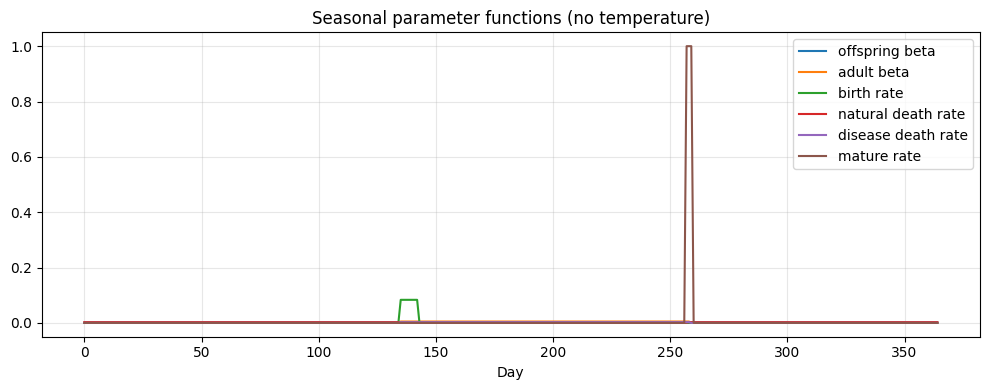

In [23]:
# =====================
# Parameter diagnostics
# =====================

beta_values = SeasonalBetaNoTemp().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
beta_adult_values = SeasonalAdultBetaNoTemp().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
birth_values = SeasonalBirths().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
death_values = SeasonalDeaths().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
disease_death_values = DiseaseMortalityNoTemp().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
mature_values = SeasonalMaturation().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(beta_values[:, 0], label="offspring beta")
ax.plot(beta_adult_values[:, 0], label="adult beta")
ax.plot(birth_values[:, 0], label="birth rate")
ax.plot(death_values[:, 0], label="natural death rate")
ax.plot(disease_death_values[:, 0], label="disease death rate")
ax.plot(mature_values[:, 0], label="mature rate")
ax.set_title("Seasonal parameter functions (no temperature)")
ax.set_xlabel("Day")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ==================
# Run the Simulation
# ==================

sim = BasicSimulator(rume)
rng_seed = 5

with sim_messaging(live=False):
    out = sim.run(rng_factory=default_rng(rng_seed))

df_out = out.dataframe
ponds = out.rume.scope.node_ids

print(df_out.head())

Running simulation (BasicSimulator):
• 2020-01-01 to 2020-12-30 (365 days)
• 3 geo nodes
  |####################| 100% 
Runtime: 0.726s
   tick       date    node  S_offspring  I_offspring  R_a_adult  R_c_adult  \
0     0 2020-01-01  Pond_A            0            0         40          0   
1     0 2020-01-01  Pond_B            0            0         30          0   
2     0 2020-01-01  Pond_C            0            0         53          3   
3     1 2020-01-02  Pond_A            0            0         40          0   
4     1 2020-01-02  Pond_B            0            0         30          0   

   S_offspring → I_offspring  S_offspring → death_exogenous  \
0                          0                              0   
1                          0                              0   
2                          0                              0   
3                          0                              0   
4                          0                              0   

   I_offspring →

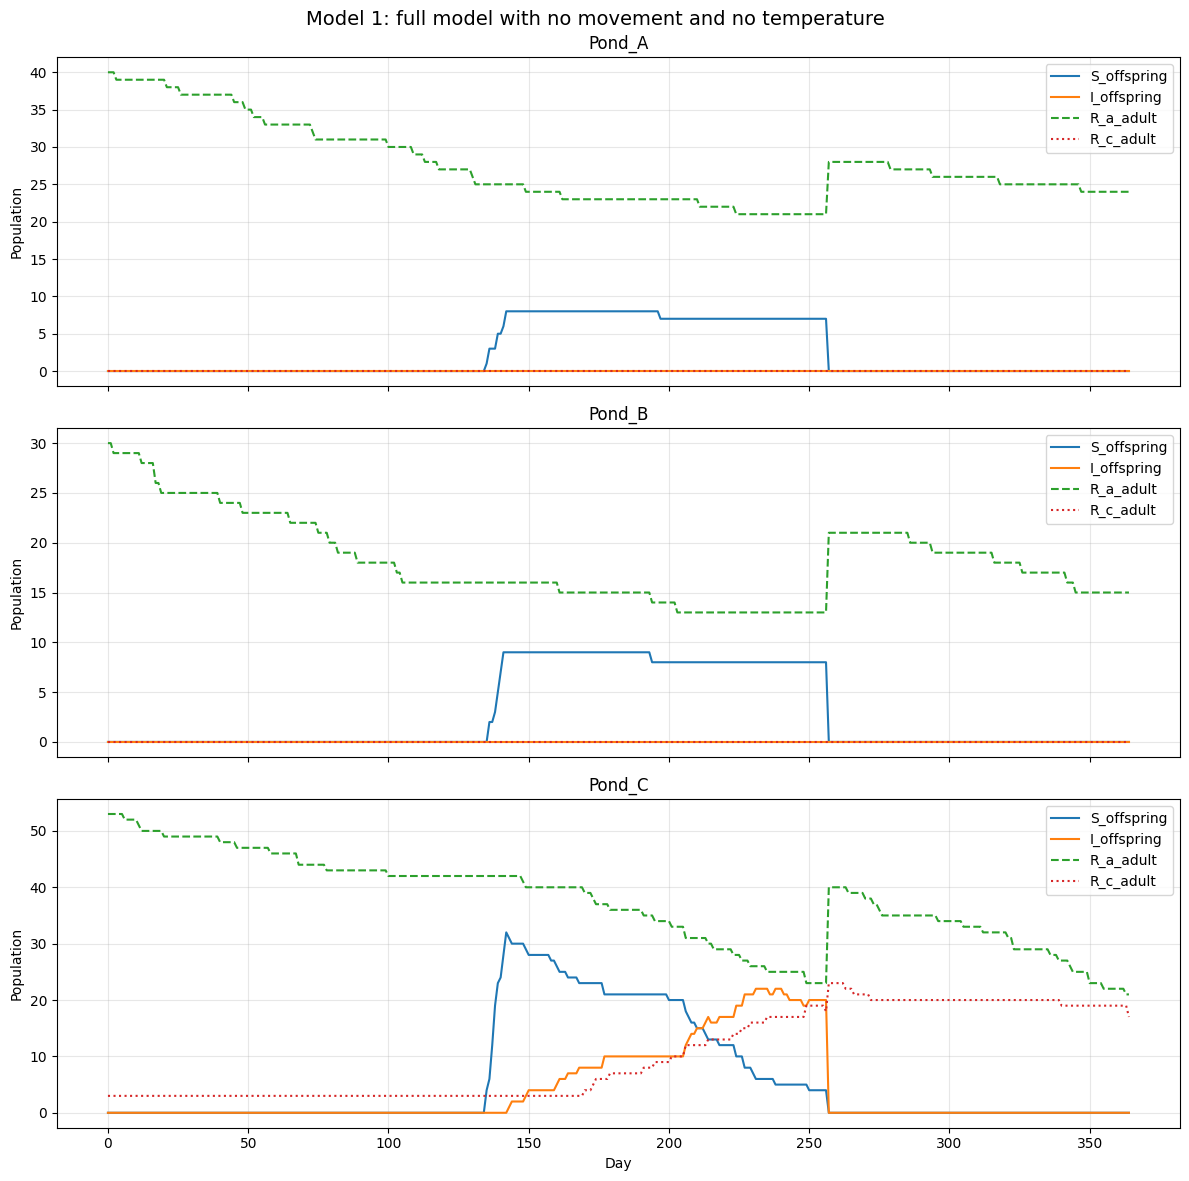

In [25]:
# ========================
# Plot simulation by pond
# ========================

fig, axes = plt.subplots(len(ponds), 1, figsize=(12, 4 * len(ponds)), sharex=True)

if len(ponds) == 1:
    axes = [axes]

for ax, pond in zip(axes, ponds):
    pond_df = df_out[df_out["node"] == pond]
    ticks = pond_df["tick"].to_numpy()

    ax.plot(ticks, pond_df["S_offspring"].to_numpy(), label="S_offspring")
    ax.plot(ticks, pond_df["I_offspring"].to_numpy(), label="I_offspring")
    ax.plot(ticks, pond_df["R_a_adult"].to_numpy(), label="R_a_adult", linestyle="--")
    ax.plot(ticks, pond_df["R_c_adult"].to_numpy(), label="R_c_adult", linestyle=":")

    ax.set_title(f"{pond}")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Day")
plt.suptitle("Model 1: full model with no movement and no temperature", fontsize=14)
plt.tight_layout()
plt.show()

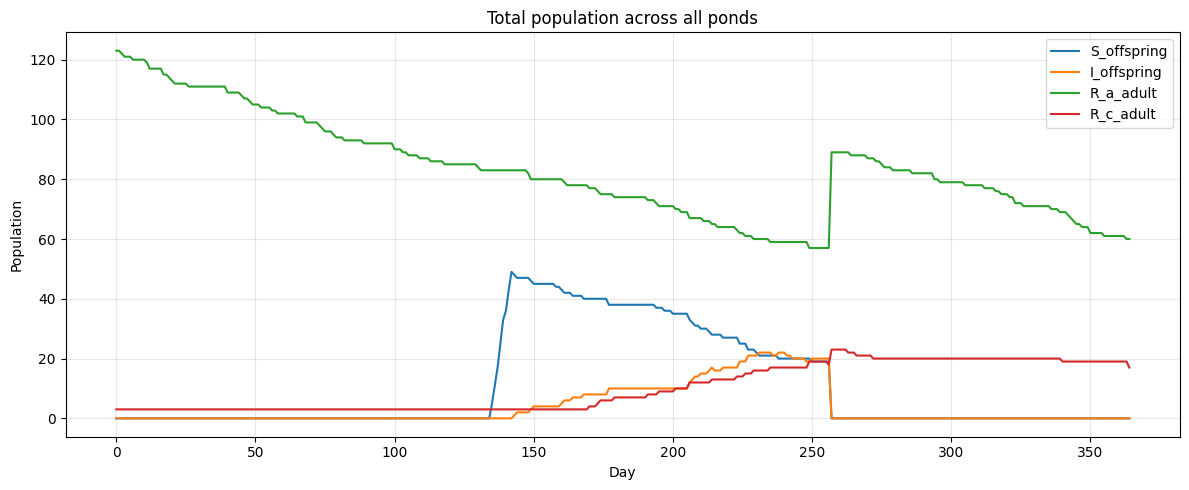

In [26]:
# =======================
# Plot total populations
# =======================

totals = df_out.groupby("tick")[["S_offspring", "I_offspring", "R_a_adult", "R_c_adult"]].sum()

fig, ax = plt.subplots(figsize=(12, 5))
for col in totals.columns:
    ax.plot(totals.index, totals[col], label=col)

ax.set_title("Total population across all ponds")
ax.set_xlabel("Day")
ax.set_ylabel("Population")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# ===========
# Diagnostics
# ===========

print("--- Total offspring around maturation (days 250-260) ---")
print(df_out.groupby("tick")[["S_offspring", "I_offspring"]].sum().loc[250:260])

print("\n--- Total adults around maturation (days 250-260) ---")
print(df_out.groupby("tick")[["R_a_adult", "R_c_adult"]].sum().loc[250:260])

print("\n--- Peak infected offspring by pond ---")
peak_I = (
    df_out.groupby("node")["I_offspring"]
    .max()
    .sort_values(ascending=False)
)
print(peak_I)

--- Total offspring around maturation (days 250-260) ---
      S_offspring  I_offspring
tick                          
250            19           20
251            19           20
252            19           20
253            19           20
254            19           20
255            19           20
256            19           20
257             0            0
258             0            0
259             0            0
260             0            0

--- Total adults around maturation (days 250-260) ---
      R_a_adult  R_c_adult
tick                      
250          57         19
251          57         19
252          57         19
253          57         19
254          57         19
255          57         19
256          57         18
257          89         23
258          89         23
259          89         23
260          89         23

--- Peak infected offspring by pond ---
node
Pond_C    22
Pond_A     0
Pond_B     0
Name: I_offspring, dtype: int64
